In [35]:
import requests  # Used to send HTTP requests and get data from the PubChem REST API
from io import StringIO  # treat text data as a file so pandas can read it easily
import pandas as pd  # for creating and working with dataframes
import numpy as np  # perform mathematical and statistical operations on data
import seaborn as sns  # for create beautiful and detailed visualizations easily
import matplotlib.pyplot as plt  # for creating basic plots and customizing visual output


1. Load the dataset into a Jupyter notebook using Pandas

In [24]:


# List of CIDs to process
cids = [2244, 1983, 702, 6322, 5957]

# Base URL parts
base_url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid"
properties = "MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA"
output_format = "csv"

# Initialize an empty list to hold data
dataframes = []

for cid in cids:
    # Construct URL
    url = f"{base_url}/{cid}/property/{properties}/{output_format}"
    print(f"Requesting: {url}")

    # Send request and read CSV data
    response = requests.get(url)
    if response.status_code == 200:
        df1 = pd.read_csv(StringIO(response.text))
        dataframes.append(df1)
    else:
        print(f"Failed to retrieve data for CID {cid}")

# Combine all dataframes into one
df = pd.concat(dataframes, ignore_index=True)

# Display the final dataframe
print(df)


Requesting: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2244/property/MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA/csv
Requesting: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/1983/property/MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA/csv
Requesting: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/702/property/MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA/csv
Requesting: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/6322/property/MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA/csv
Requesting: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/5957/property/MolecularWeight,HBondDonorCount,HBondAcceptorCount,HeavyAtomCount,XLogP,TPSA/csv
    CID  MolecularWeight  HBondDonorCount  HBondAcceptorCount  HeavyAtomCount  \
0  2244           180.16                1                   4              13   
1  1983           151.16     

2. Inspect the data: Check column names, data types, and handle any missing values.

In [25]:
df.head  #display the top 5 row in df

<bound method NDFrame.head of     CID  MolecularWeight  HBondDonorCount  HBondAcceptorCount  HeavyAtomCount  \
0  2244           180.16                1                   4              13   
1  1983           151.16                2                   2              11   
2   702            46.07                1                   1               3   
3  6322           174.20                4                   4              12   
4  5957           507.18                7                  17              31   

   XLogP   TPSA  
0    1.2   63.6  
1    0.5   49.3  
2   -0.1   20.2  
3   -4.2  128.0  
4   -5.7  279.0  >

In [26]:
print(df.shape)
#get the number of rows and columns in dataset

(5, 7)


In [27]:
df.values

array([[ 2.2440e+03,  1.8016e+02,  1.0000e+00,  4.0000e+00,  1.3000e+01,
         1.2000e+00,  6.3600e+01],
       [ 1.9830e+03,  1.5116e+02,  2.0000e+00,  2.0000e+00,  1.1000e+01,
         5.0000e-01,  4.9300e+01],
       [ 7.0200e+02,  4.6070e+01,  1.0000e+00,  1.0000e+00,  3.0000e+00,
        -1.0000e-01,  2.0200e+01],
       [ 6.3220e+03,  1.7420e+02,  4.0000e+00,  4.0000e+00,  1.2000e+01,
        -4.2000e+00,  1.2800e+02],
       [ 5.9570e+03,  5.0718e+02,  7.0000e+00,  1.7000e+01,  3.1000e+01,
        -5.7000e+00,  2.7900e+02]])

In [28]:
df.describe #get the

<bound method NDFrame.describe of     CID  MolecularWeight  HBondDonorCount  HBondAcceptorCount  HeavyAtomCount  \
0  2244           180.16                1                   4              13   
1  1983           151.16                2                   2              11   
2   702            46.07                1                   1               3   
3  6322           174.20                4                   4              12   
4  5957           507.18                7                  17              31   

   XLogP   TPSA  
0    1.2   63.6  
1    0.5   49.3  
2   -0.1   20.2  
3   -4.2  128.0  
4   -5.7  279.0  >

In [29]:
#data types
df.info()  #Number of rows and columns,Column names,Data types of each column,Non-null (non-missing) counts per column,Memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CID                 5 non-null      int64  
 1   MolecularWeight     5 non-null      float64
 2   HBondDonorCount     5 non-null      int64  
 3   HBondAcceptorCount  5 non-null      int64  
 4   HeavyAtomCount      5 non-null      int64  
 5   XLogP               5 non-null      float64
 6   TPSA                5 non-null      float64
dtypes: float64(3), int64(4)
memory usage: 412.0 bytes


In [30]:
#handle any missing values
df.isnull().sum()

,0
CID,0
MolecularWeight,0
HBondDonorCount,0
HBondAcceptorCount,0
HeavyAtomCount,0
XLogP,0
TPSA,0


3. Perform basic data cleaning if needed.
    No missing values
    Find outliers

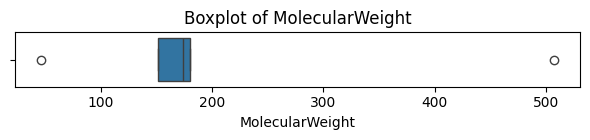

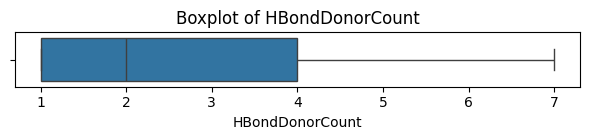

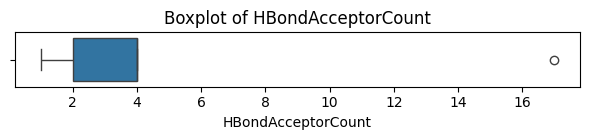

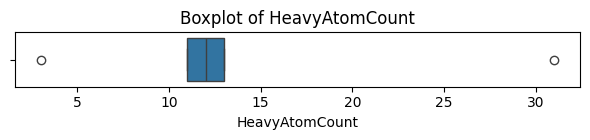

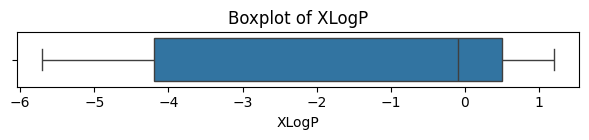

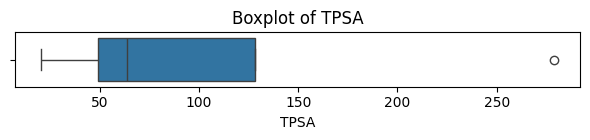

In [32]:
#box plot
columns_to_plot = [
    'MolecularWeight',
    'HBondDonorCount',
    'HBondAcceptorCount',
    'HeavyAtomCount',
    'XLogP',
    'TPSA'
]

# Loop through each column and plot
for col in columns_to_plot:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=final_df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

1. MolecularWeight: There are a few data points significantly higher than the majority of the data, indicating potential outliers.
2. HBondDonorCount: While less pronounced than MolecularWeight, there might be a few outliers on the higher end.
HBondAcceptorCount: Similar to HBondDonorCount, there could be a few outliers on the higher end.
3. HeavyAtomCount: This column shows potential outliers on the higher end, similar to MolecularWeight.
4. XLogP: A few data points appear to be outliers on both the lower and higher ends.

outliers remval using IQR method

In [36]:
from scipy import stats
df_no_outliers = df[(np.abs(stats.zscore(df.select_dtypes(include=[np.number]))) < 3).all(axis=1)]


In [37]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_iqr = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]


In [40]:
df.describe

<bound method NDFrame.describe of     CID  MolecularWeight  HBondDonorCount  HBondAcceptorCount  HeavyAtomCount  \
0  2244           180.16                1                   4              13   
1  1983           151.16                2                   2              11   
2   702            46.07                1                   1               3   
3  6322           174.20                4                   4              12   
4  5957           507.18                7                  17              31   

   XLogP   TPSA  
0    1.2   63.6  
1    0.5   49.3  
2   -0.1   20.2  
3   -4.2  128.0  
4   -5.7  279.0  >

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df.drop('CID', axis=1)), columns=df.columns[1:])


Encoding – Not needed here
All your features are numeric, so no label or one-hot encoding is required.


5. Visualize at least 2 property


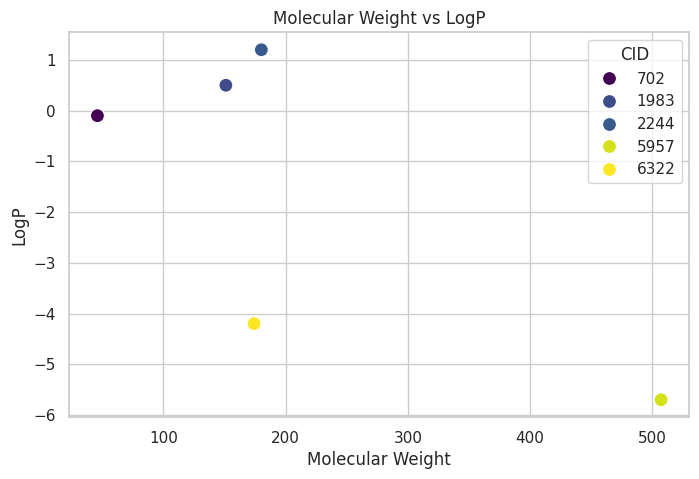

In [41]:

sns.set(style="whitegrid") #for getting the grid whih el to clarly unerstand the  patterns and values

# Plot Molecular Weight vs XLogP
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="MolecularWeight", y="XLogP", hue="CID", palette="viridis", s=100)
plt.title("Molecular Weight vs LogP")
plt.xlabel("Molecular Weight")
plt.ylabel("LogP")
plt.show()

The scatter plot visualizes the relationship between Molecular Weight and XLogP (lipophilicity) for five compounds, distinguished by unique CIDs and color-coded using the 'viridis' palette.
    It reveals a general trend where compounds with higher molecular weight tend to exhibit increased lipophilicity (higher XLogP values), although the relationship isn't strictly linear.
    This visualization provides insights into the physicochemical properties of these compounds, which can inform decisions in drug development, such as solvent selection and formulation optimization.

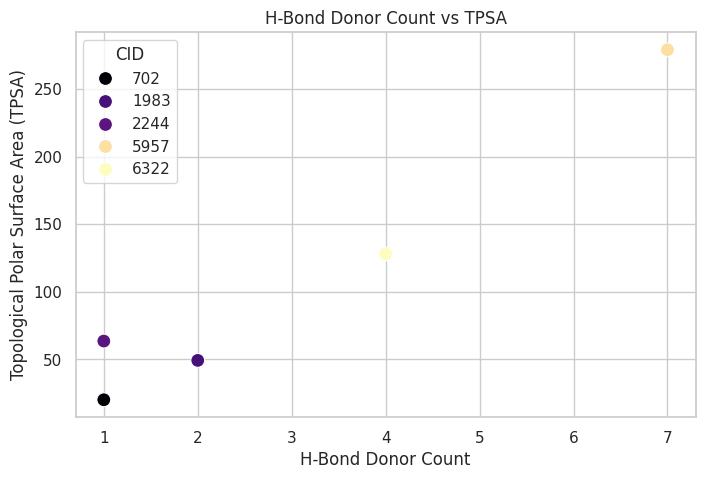

In [42]:
# Plot HBondDonor vs TPSA
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="HBondDonorCount", y="TPSA", hue="CID", palette="magma", s=100)
plt.title("H-Bond Donor Count vs TPSA")
plt.xlabel("H-Bond Donor Count")
plt.ylabel("Topological Polar Surface Area (TPSA)")
plt.show()

The scatter plot illustrates the relationship between H-Bond Donor Count and Topological Polar Surface Area (TPSA) for five compounds, color-coded by CID using the 'magma' palette, suggesting a potential correlation between these two properties that can influence solvent selection in drug development.
    As the number of H-bond donors increases, the TPSA value also tends to increase, indicating that compounds with more potential for hydrogen bonding exhibit a larger polar surface area. This trend is expected, as H-bond donors contribute significantly to a molecule's polarity and its ability to interact with polar solvents. This observation can be valuable in drug development, as it suggests that compounds with higher H-bond donor counts and TPSA values may be more soluble in polar solvents, influencing solvent selection for formulation and delivery.

6. Bonus (Optional): Explain how trends in these molecular properties can support solvent selection in drug development.


**Molecular Weight (MW)**: Compounds with high molecular weight often have lower solubility in water and may require organic solvents (e.g., ethanol, DMSO) for formulation. Lower MW drugs are more likely to be soluble in aqueous solvents, which are preferred for oral or intravenous delivery.

**XLogP (Partition Coefficient, LogP)**: Indicates lipophilicity (how well the drug dissolves in fats vs. water).
High LogP (>3) compounds are lipophilic, poorly soluble in water — thus, require non-polar solvents like hexane or ethyl acetate.
Low LogP (< 1) indicates better water solubility, allowing aqueous solvents to be used.

**TPSA (Topological Polar Surface Area):** Reflects the drug’s ability to form hydrogen bonds, which influences absorption and permeability. High TPSA (>140 Å²) suggests poor membrane permeability, and water solubility — needs polar solvents. Low TPSA drugs are more lipophilic — suited for non-polar solvents.

**H-Bond Donor/Acceptor Count**: Affects hydrogen bonding with the solvent. Drugs with more H-bond donors/acceptors tend to favor hydrophilic solvents like water or methanol. Fewer donors/acceptors suggest lipophilic behavior, requiring organic solvents.

**Heavy Atom Count**: Generally correlates with MW and size. Larger molecules may require solvents with higher solvating power due to steric hindrance